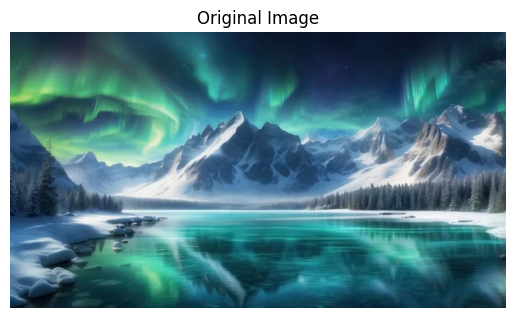

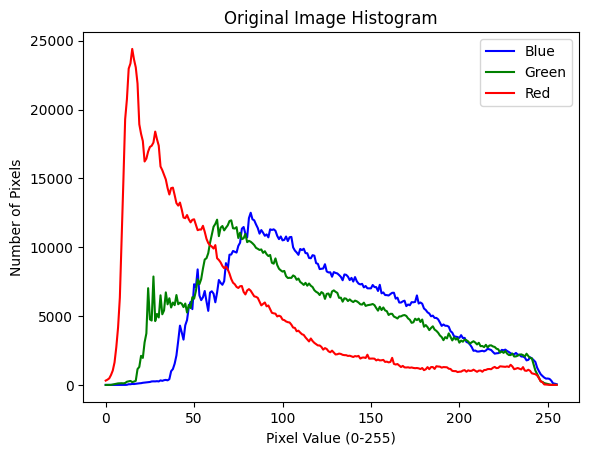

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\Harshita Sinha\OneDrive\Pictures\Screenshots\image-2.png")

# Safety check
if img is None:
    print("Image not loaded!")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

plt.plot(cv2.calcHist([img], [0], None, [256], [0,256]), color='blue', label='Blue')
plt.plot(cv2.calcHist([img], [1], None, [256], [0,256]), color='green', label='Green')
plt.plot(cv2.calcHist([img], [2], None, [256], [0,256]), color='red', label='Red')
plt.title("Original Image Histogram")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Number of Pixels")
plt.legend()
plt.show()

(866, 1557)


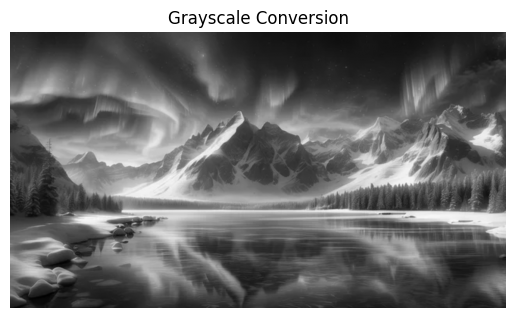

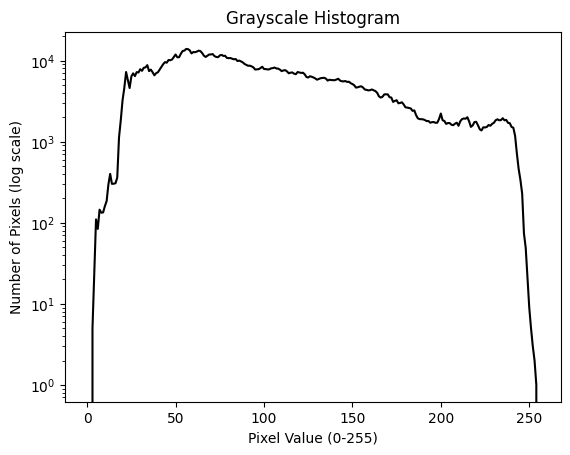

In [49]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gray.shape)  # (731, 1459) — no channel dimension, just brightness values
plt.imshow(gray, cmap = 'gray')
plt.title("Grayscale Conversion")
plt.axis("off")
plt.show()


plt.plot(cv2.calcHist([gray], [0], None, [256], [0,256]), color='black')
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Number of Pixels (log scale)")
plt.yscale('log')   # compresses tall spikes so everything is visible
plt.show()

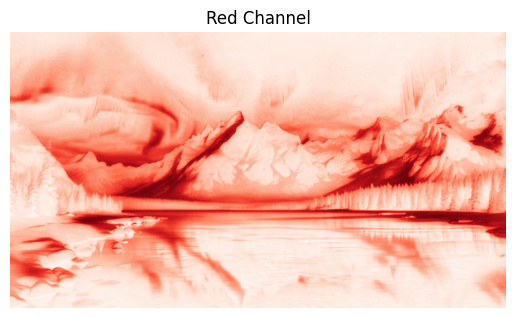

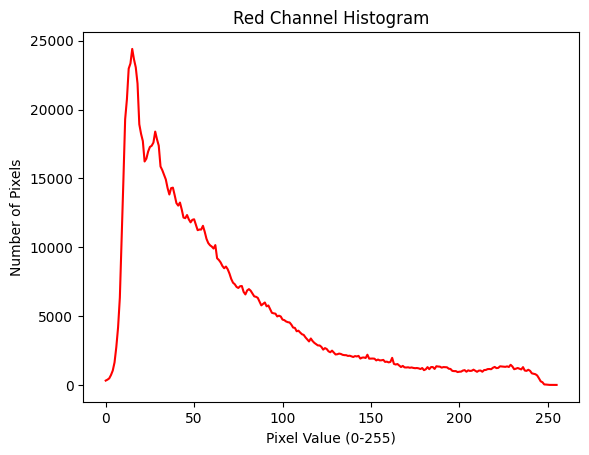

In [50]:
R = img[:, :, 2]   # index 2 because cv2 loads as BGR

plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")
plt.show()

plt.plot(cv2.calcHist([img], [2], None, [256], [0,256]), color='red')
plt.title("Red Channel Histogram")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Number of Pixels")
plt.show()

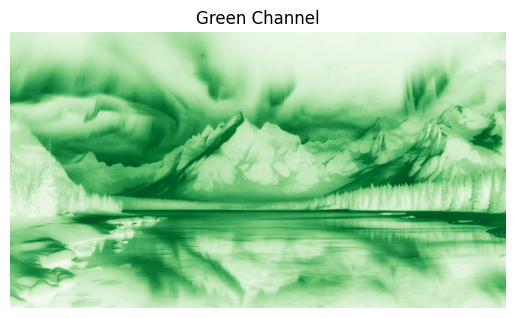

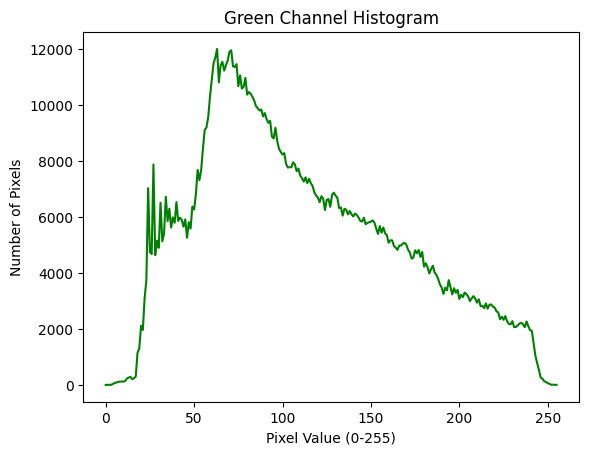

In [51]:
G = img[:, :, 1]   # index 1 for Green

plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")
plt.show()


plt.plot(cv2.calcHist([img], [1], None, [256], [0,256]), color='green')
plt.title("Green Channel Histogram")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Number of Pixels")
plt.show()

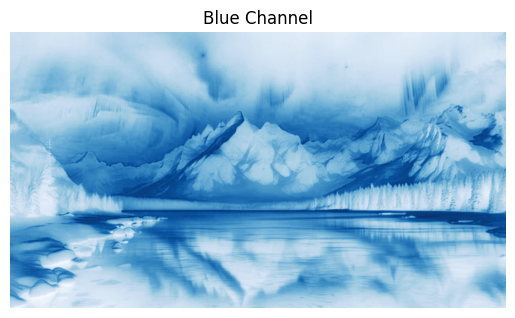

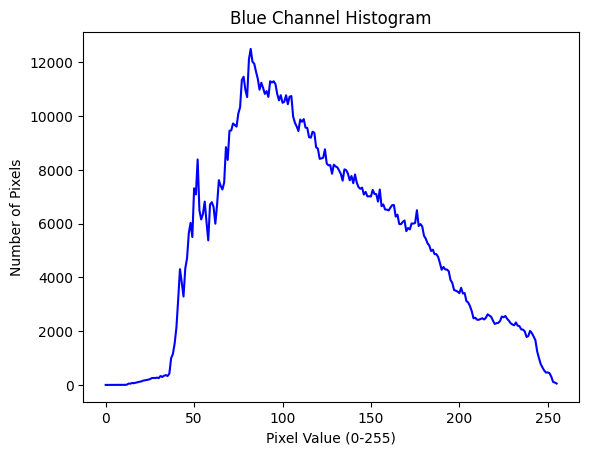

In [52]:
B = img[:, :, 0]   # index 0 because BGR — Blue comes first

plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")
plt.show()

plt.plot(cv2.calcHist([img], [0], None, [256], [0,256]), color='blue')
plt.title("Blue Channel Histogram")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Number of Pixels")
plt.show()

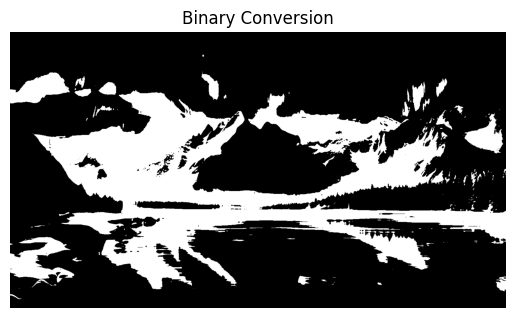

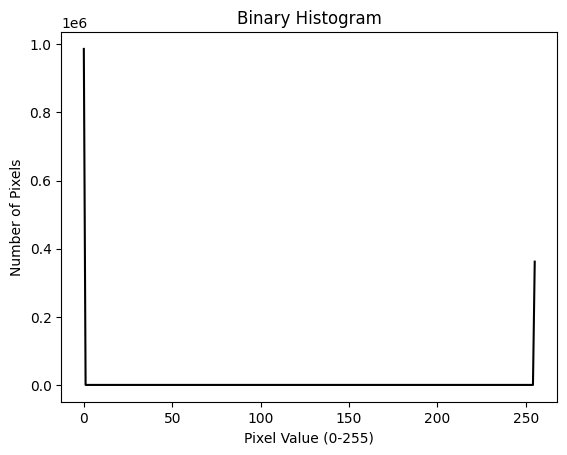

In [53]:
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title("Binary Conversion")
plt.axis("off")
plt.show()

plt.plot(cv2.calcHist([binary], [0], None, [256], [0,256]), color='black')
plt.title("Binary Histogram")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Number of Pixels")
plt.show()

Original shape: (866, 1557, 3)
Resized shape: (75, 150, 3)


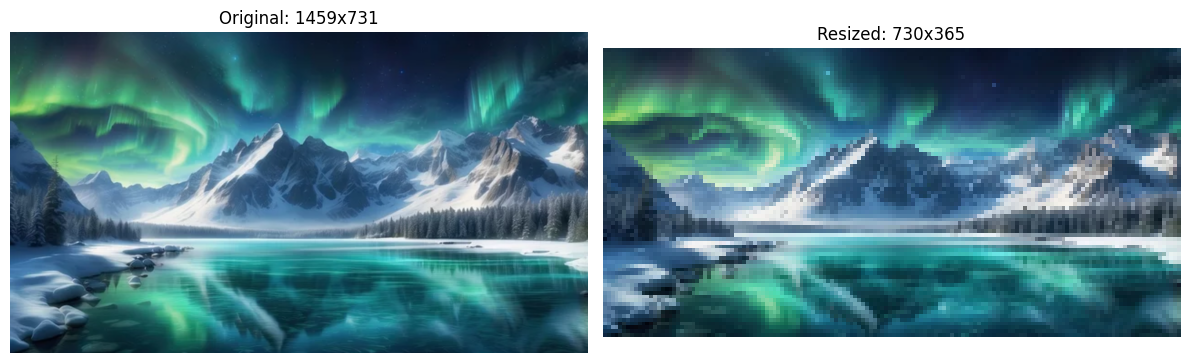

In [54]:
img_resized = cv2.resize(img, (150, 75))  # (width, height) — half the original size

print("Original shape:", img.shape)        # (731, 1459, 3)
print("Resized shape:", img_resized.shape) # (150, 75, 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original: 1459x731")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
axes[1].set_title("Resized: 730x365")
axes[1].axis("off")

plt.tight_layout()
plt.show()

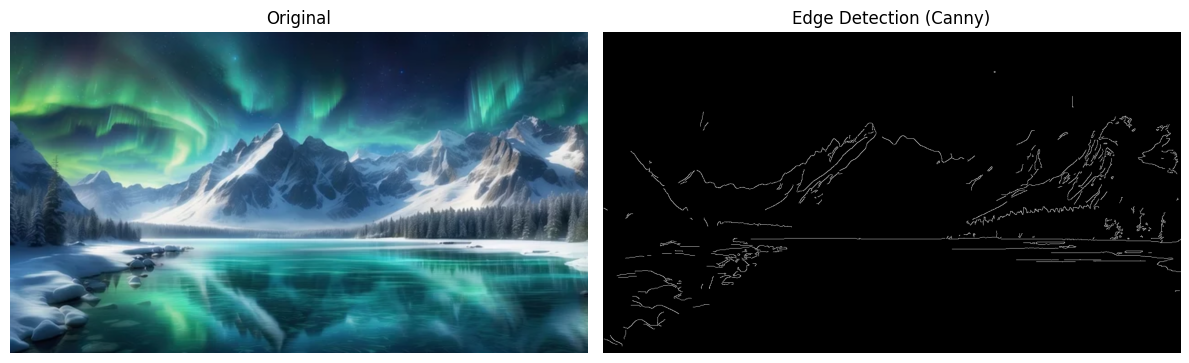

In [55]:
edges = cv2.Canny(gray, 100, 200)   # (image, low_threshold, high_threshold)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(edges, cmap='gray')
axes[1].set_title("Edge Detection (Canny)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [56]:
# Generate random noise with mean=0, std=25, same size as image
noise = np.random.normal(0, 25, img.shape).astype(np.int16)

# Add noise to image (careful with dtype to avoid overflow)
img_noisy = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

In [57]:
# (5,5) is the kernel size — how many neighbours to consider
img_denoised = cv2.GaussianBlur(img_noisy, (5,5), 0)

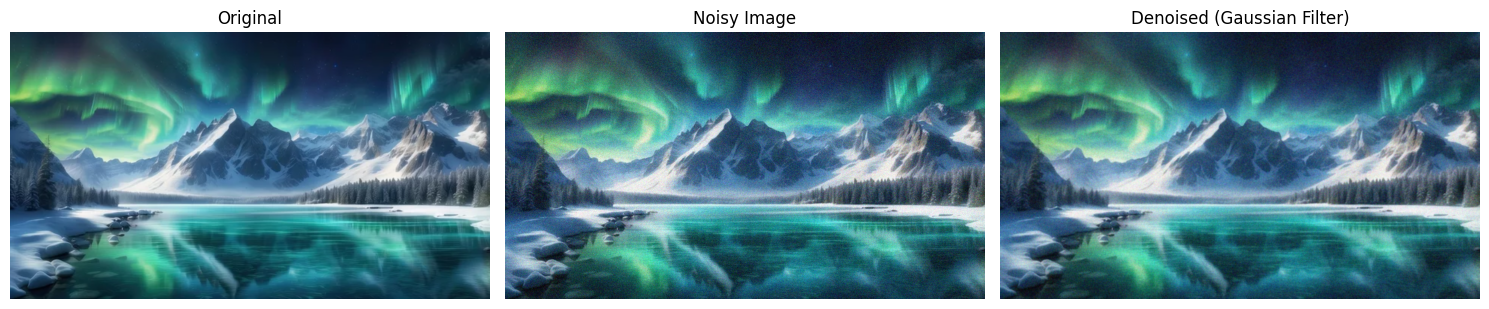

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_noisy, cv2.COLOR_BGR2RGB))
axes[1].set_title("Noisy Image")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_denoised, cv2.COLOR_BGR2RGB))
axes[2].set_title("Denoised (Gaussian Filter)")
axes[2].axis("off")

plt.tight_layout()
plt.show()